In [2]:
import sys
sys.path.append("..")
import torch
from components.model import GPTModel

torch version 2.12.1
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention weights:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
tensor([0.4419, 0.6515, 0.5683])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070

In [3]:
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256,
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
"qkv_bias": False
}

torch.manual_seed(123)
model= GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [4]:
import tiktoken
from components.model import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded= tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor =torch.tensor(encoded).unsqueeze(0)  #ads batch dimension
    return encoded_tensor
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist()) #removes batch dimension

start_context ="Attention is all you need"
tokenizer= tiktoken.get_encoding("gpt2")
token_ids= generate_text_simple(model=model, idx=text_to_token_ids(start_context, tokenizer), max_new_tokens=10, context_size=GPT_CONFIG_124M["context_length"])

print("Output text: \n", token_ids_to_text(token_ids, tokenizer))

Output text: 
 Attention is all you need lettuce Imperium96 VIDEOS Royale sanct sellers Supportedettingatural


In [5]:
# text gen loss
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
[40, 1107, 588]]) # "I really like"]
targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
[1107, 588, 11311]]) # " really like chocolate"]
with torch.no_grad():
    logits= model(inputs)
probas= torch.softmax(logits, dim=-1)
print(probas.shape)     

torch.Size([2, 3, 50257])


In [6]:
token_ids= torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs: ", token_ids)

Token IDs:  tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [7]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [8]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])
tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [9]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [10]:
logits_flat =logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [11]:
loss =torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [12]:
file_path= "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data=file.read()

In [13]:
total_chars =len(text_data)
total_tokens =len(tokenizer.encode(text_data))
print("Characters: ", total_chars)
print("Tokens: ", total_tokens)

Characters:  20479
Tokens:  5145


In [14]:
# training and validation dataset
train_ratio =0.9 #90% of data fr trraining and rest for validation
split_idx =int(train_ratio*len(text_data))
train_data =text_data[:split_idx]
val_data =text_data[split_idx:]

In [15]:
from utils.dataloader import create_dataloader_v1
torch.manual_seed(123)
 
train_loader= create_dataloader_v1(train_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=True, shuffle=True, num_workers=0)
val_loader= create_dataloader_v1(train_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=False, shuffle=False, num_workers=0)


[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [16]:
print("Train Loader: ")
for x, y in train_loader:
    print(x.shape, y.shape)
print("Validation Loader: ")
for x, y in val_loader:
    print(x.shape, y.shape)

Train Loader: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Validation Loader: 
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [17]:
# calculatin cross entropy loss of given batch
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch= input_batch.to(device)
    target_batch =target_batch.to(device)
    logits =model(input_batch)
    loss =torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [18]:
# computing training and validation loss
def calc_loss_loader(data_loader,model, device, num_batches=None):
    total_loss =0
    if len(data_loader)== 0:
        return float("nan")
    elif num_batches is None:
        num_batches =len(data_loader)
    else:
        num_batches =min(num_batches, len(data_loader))

    # reduces no of batches to match total no of batches in data loader if num_batches exceeds no of batches in data loader
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i <num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss +=loss.item()
        else:
            break
    return total_loss/ num_batches

In [19]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss= calc_loss_loader(train_loader, model, device)
    val_loss =calc_loss_loader(val_loader, model, device)

print("Training loss: ", train_loss)
print("Validation loss: ", val_loss)    

Training loss:  10.987583584255642
Validation loss:  10.987583690219456


In [20]:
# pretraining llm
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq,eval_iter,start_context, tokenizer):
    #lists to track token losses and tokens seen
    train_losses, val_losses, track_token_seen= [],[], []
    tokens_seen, global_step= 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   #restes loss gradients from prevbatch iteration
            loss =calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() #calculatin loss gradients
            optimizer.step() #updates model weights using loss gradients
            tokens_seen +=input_batch.numel()
            global_step += 1

            # optimal evaluation step
            if global_step%eval_freq== 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_token_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                f"Train loss {train_loss:.3f}, "
                f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses,track_token_seen

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size =model.pos_emb.weight.shape[0]
    encoded= text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids= generate_text_simple(model=model,idx=encoded, max_new_tokens=50, context_size=context_size)

    decoded_text =token_ids_to_text(token_ids,tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

# calculates loss oveer training and validation set while ensuring model is in eval mode with gradient tracking annd droput disabled
def evaluate_model(model, train_loader, val_loader,device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss= calc_loss_loader(train_loader, model, device,num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        model.train()

    return train_loss, val_loss

In [21]:
torch.manual_seed(123)
model= GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs= 10
train_losses, val_losses, tokens_seen = train_model_simple(model,train_loader, val_loader,optimizer,device, num_epochs=num_epochs, eval_freq=5, eval_iter=5,start_context="Every effort moves you",tokenizer=tokenizer)


Ep 1 (Step 000000): Train loss 9.781, Val loss 9.841
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.239
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 6.874
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.236
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 5.943
Ep 3 (Step 000025): Train loss 5.201, Val loss 5.468
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 4.962
Ep 4 (Step 000035): Train loss 4.069, Val loss 4.379
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 3.894
Every effort moves you know it was not that the picture--I had the fact by the last

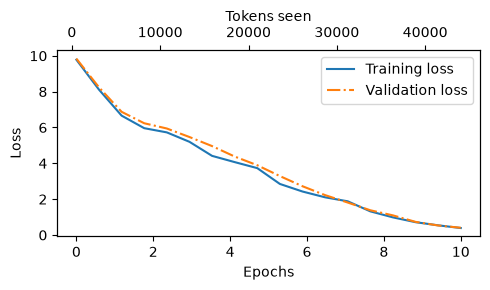

In [22]:
# plot for training and validation set losses
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig,ax1 =plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor= torch.linspace(0, num_epochs,len(train_losses))
plot_losses(epochs_tensor, tokens_seen,train_losses,val_losses)